# RL Analysis Plots

This notebook collects the DQN and SAC plots used in the homework analysis.

In [28]:
from pathlib import Path
import csv
import matplotlib.pyplot as plt

In [29]:
def load_metric_curve(log_csv_path, metric_name):
    steps = []
    values = []

    with open(log_csv_path, newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            step = row.get("step", "")
            value = row.get(metric_name, "")

            if not step or not value:
                continue

            steps.append(float(step))
            values.append(float(value))

    if not steps:
        raise ValueError(f"No points found for {metric_name} in {log_csv_path}")

    return steps, values


def latest_log(pattern):
    matches = sorted(Path("../exp").glob(pattern))
    if not matches:
        raise FileNotFoundError(f"No log matched pattern: {pattern}")
    return matches[-1]


## DQN: CartPole and LunarLander

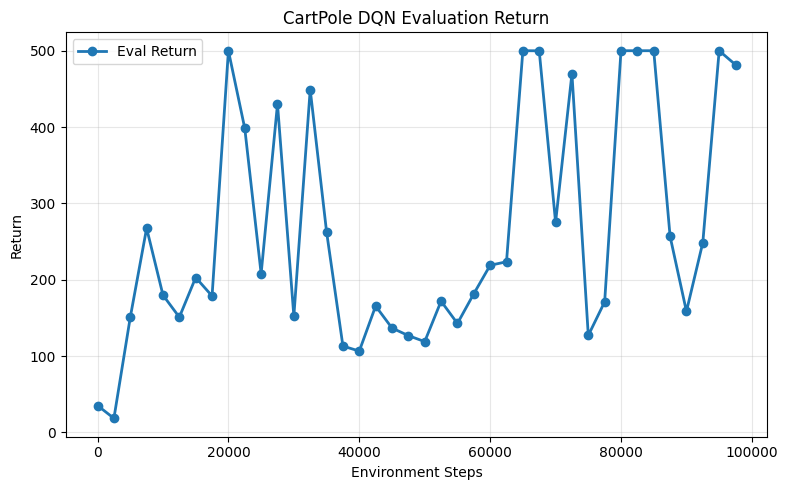

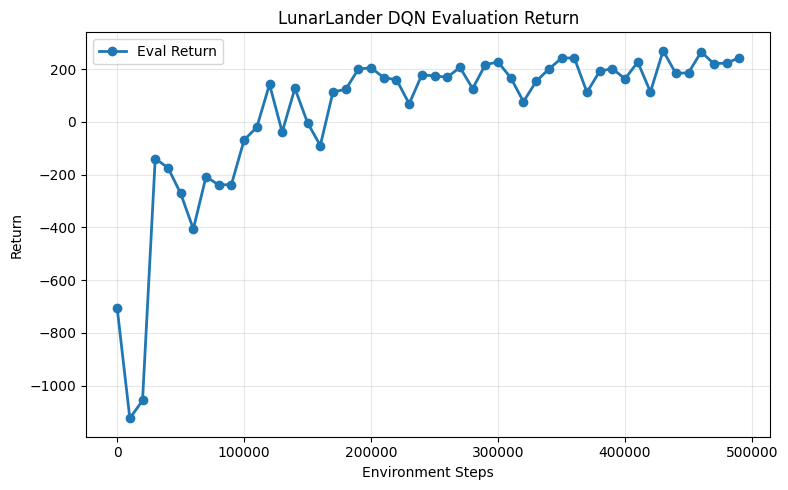

In [30]:
dqn_eval_logs = {
    "CartPole": latest_log("CartPole-v1_dqn_*/log.csv"),
    "LunarLander": latest_log("LunarLander-v2_dqn_*/log.csv"),
}

for env_name, log_path in dqn_eval_logs.items():
    steps, eval_returns = load_metric_curve(log_path, "Eval_AverageReturn")

    plt.figure(figsize=(8, 5))
    plt.plot(steps, eval_returns, marker="o", linewidth=2, label="Eval Return")
    plt.xlabel("Environment Steps")
    plt.ylabel("Return")
    plt.title(f"{env_name} DQN Evaluation Return")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

## DQN: MsPacman Train and Eval

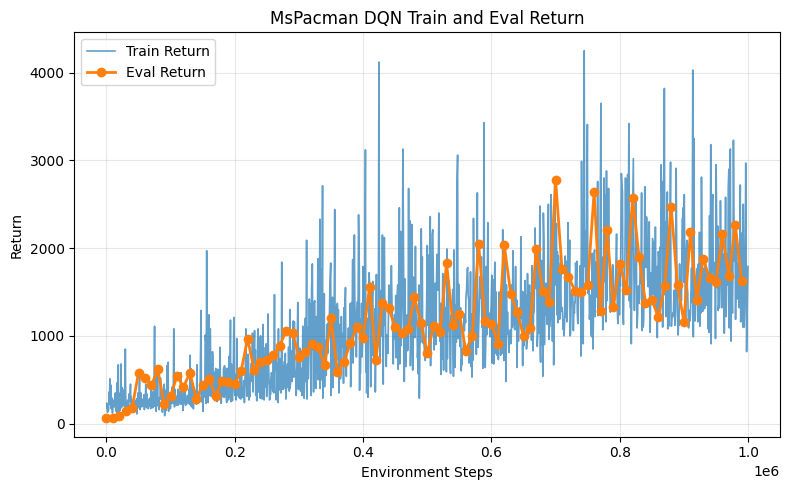

In [31]:
pacman_log_path = latest_log("MsPacman_dqn_*/log.csv")
train_steps, train_returns = load_metric_curve(pacman_log_path, "Train_EpisodeReturn")
eval_steps, eval_returns = load_metric_curve(pacman_log_path, "Eval_AverageReturn")

plt.figure(figsize=(8, 5))
plt.plot(train_steps, train_returns, linewidth=1.2, alpha=0.7, label="Train Return")
plt.plot(eval_steps, eval_returns, marker="o", linewidth=2, label="Eval Return")
plt.xlabel("Environment Steps")
plt.ylabel("Return")
plt.title("MsPacman DQN Train and Eval Return")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## DQN: LunarLander Hyperparameter Comparison

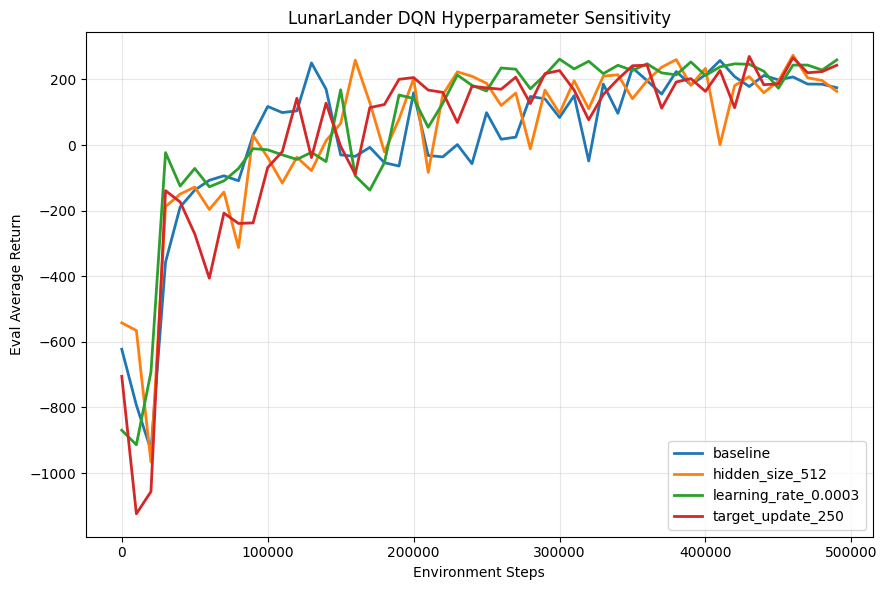

In [33]:
baseline_like_logs = sorted(Path("../exp").glob("LunarLander-v2_dqn_sd1_*/log.csv"))

lunarlander_runs = {
    "baseline": baseline_like_logs[0],
    "hidden_size_512": latest_log("LunarLander-v2_dqn_hidden_size_512_sd1_*/log.csv"),
    "learning_rate_0.0003": latest_log("LunarLander-v2_dqn_lr_0p0003_sd1_*/log.csv"),
    "target_update_250": latest_log("LunarLander-v2_dqn_target_update_250_sd1_*/log.csv"),
}

plt.figure(figsize=(9, 6))
for label, log_path in lunarlander_runs.items():
    steps, eval_returns = load_metric_curve(log_path, "Eval_AverageReturn")
    plt.plot(steps, eval_returns, linewidth=2, label=label)

plt.xlabel("Environment Steps")
plt.ylabel("Eval Average Return")
plt.title("LunarLander DQN Hyperparameter Sensitivity")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## SAC: HalfCheetah Eval Return

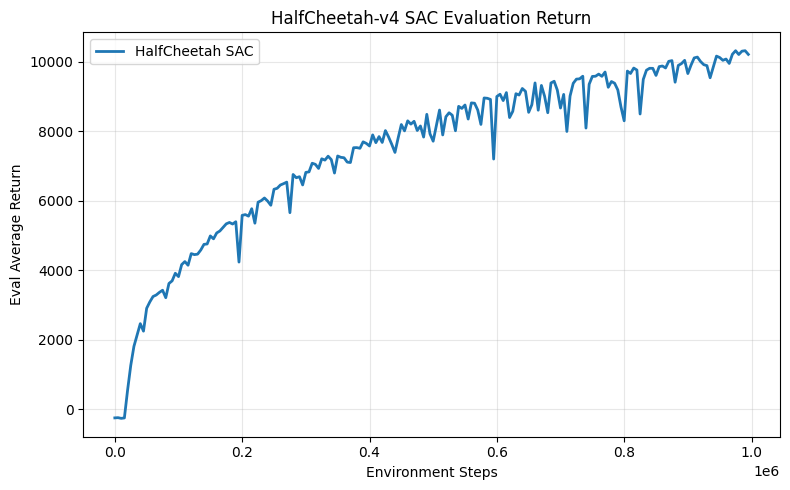

In [44]:
halfcheetah_log = latest_log("HalfCheetah-v4_sac_sd*/log.csv")
steps, eval_returns = load_metric_curve(halfcheetah_log, "Eval_AverageReturn")

plt.figure(figsize=(8, 5))
plt.plot(steps, eval_returns, linewidth=2, label="HalfCheetah SAC")
plt.xlabel("Environment Steps")
plt.ylabel("Eval Average Return")
plt.title("HalfCheetah-v4 SAC Evaluation Return")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## SAC: Fixed Temperature vs Auto-Tuned Temperature

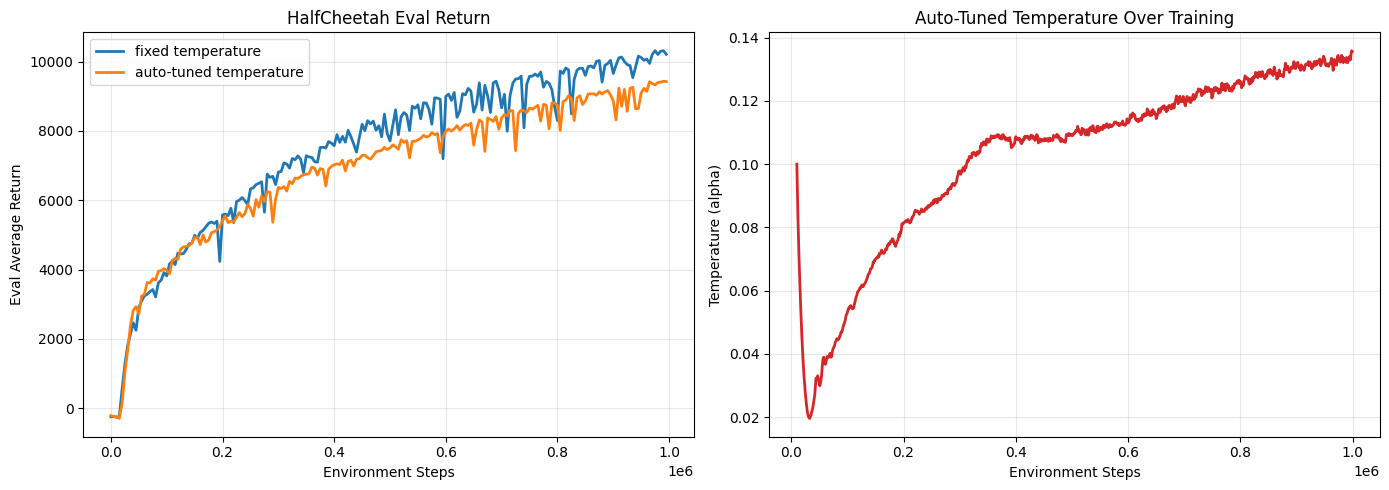

In [46]:
halfcheetah_fixed_log = latest_log("HalfCheetah-v4_sac_sd*/log.csv")
halfcheetah_autotune_log = latest_log("HalfCheetah-v4_sac_autotune_sd*/log.csv")

fixed_steps, fixed_eval_returns = load_metric_curve(halfcheetah_fixed_log, "Eval_AverageReturn")
autotune_steps, autotune_eval_returns = load_metric_curve(halfcheetah_autotune_log, "Eval_AverageReturn")
alpha_steps, alpha_values = load_metric_curve(halfcheetah_autotune_log, "temperature")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fixed_steps, fixed_eval_returns, linewidth=2, label="fixed temperature")
axes[0].plot(autotune_steps, autotune_eval_returns, linewidth=2, label="auto-tuned temperature")
axes[0].set_xlabel("Environment Steps")
axes[0].set_ylabel("Eval Average Return")
axes[0].set_title("HalfCheetah Eval Return")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(alpha_steps, alpha_values, linewidth=2, color="tab:red")
axes[1].set_xlabel("Environment Steps")
axes[1].set_ylabel("Temperature (alpha)")
axes[1].set_title("Auto-Tuned Temperature Over Training")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## SAC: Hopper Single-Q vs Clipped Double-Q

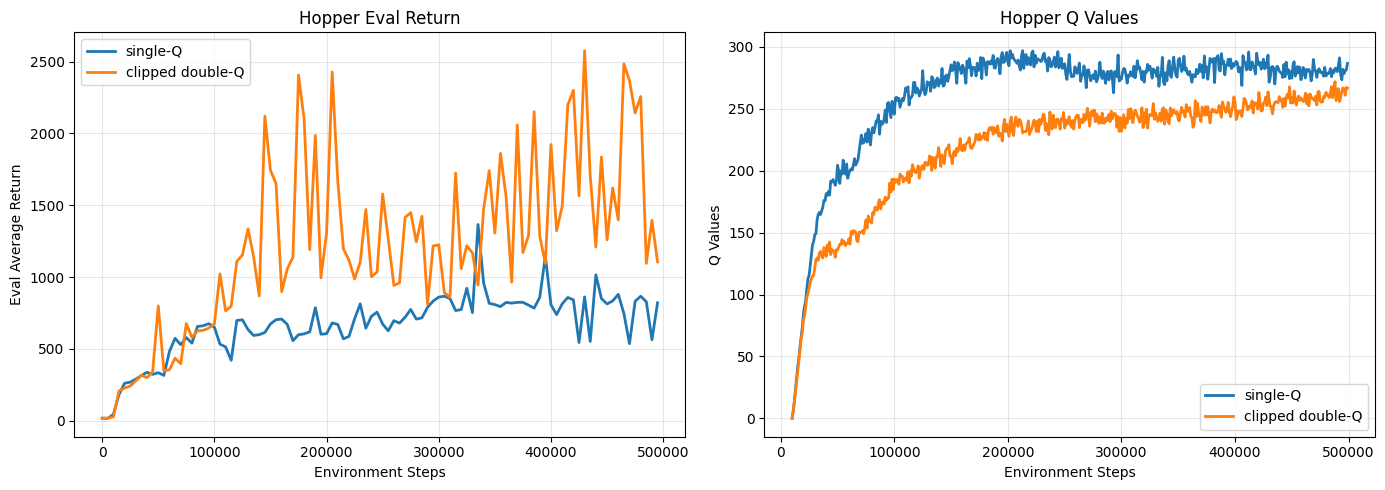

In [43]:
hopper_singleq_log = latest_log("Hopper-v4_sac_singleq_sd*/log.csv")
hopper_clipq_log = latest_log("Hopper-v4_sac_clipq_sd*/log.csv")

singleq_eval_steps, singleq_eval_returns = load_metric_curve(hopper_singleq_log, "Eval_AverageReturn")
clipq_eval_steps, clipq_eval_returns = load_metric_curve(hopper_clipq_log, "Eval_AverageReturn")
singleq_q_steps, singleq_q_values = load_metric_curve(hopper_singleq_log, "q_values")
clipq_q_steps, clipq_q_values = load_metric_curve(hopper_clipq_log, "q_values")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(singleq_eval_steps, singleq_eval_returns, linewidth=2, label="single-Q")
axes[0].plot(clipq_eval_steps, clipq_eval_returns, linewidth=2, label="clipped double-Q")
axes[0].set_xlabel("Environment Steps")
axes[0].set_ylabel("Eval Average Return")
axes[0].set_title("Hopper Eval Return")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(singleq_q_steps, singleq_q_values, linewidth=2, label="single-Q")
axes[1].plot(clipq_q_steps, clipq_q_values, linewidth=2, label="clipped double-Q")
axes[1].set_xlabel("Environment Steps")
axes[1].set_ylabel("Q Values")
axes[1].set_title("Hopper Q Values")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()